R_f = 25.00
f = 2.12
R_h = 26.00
P = 96.36
Helix angle = 59.46 deg


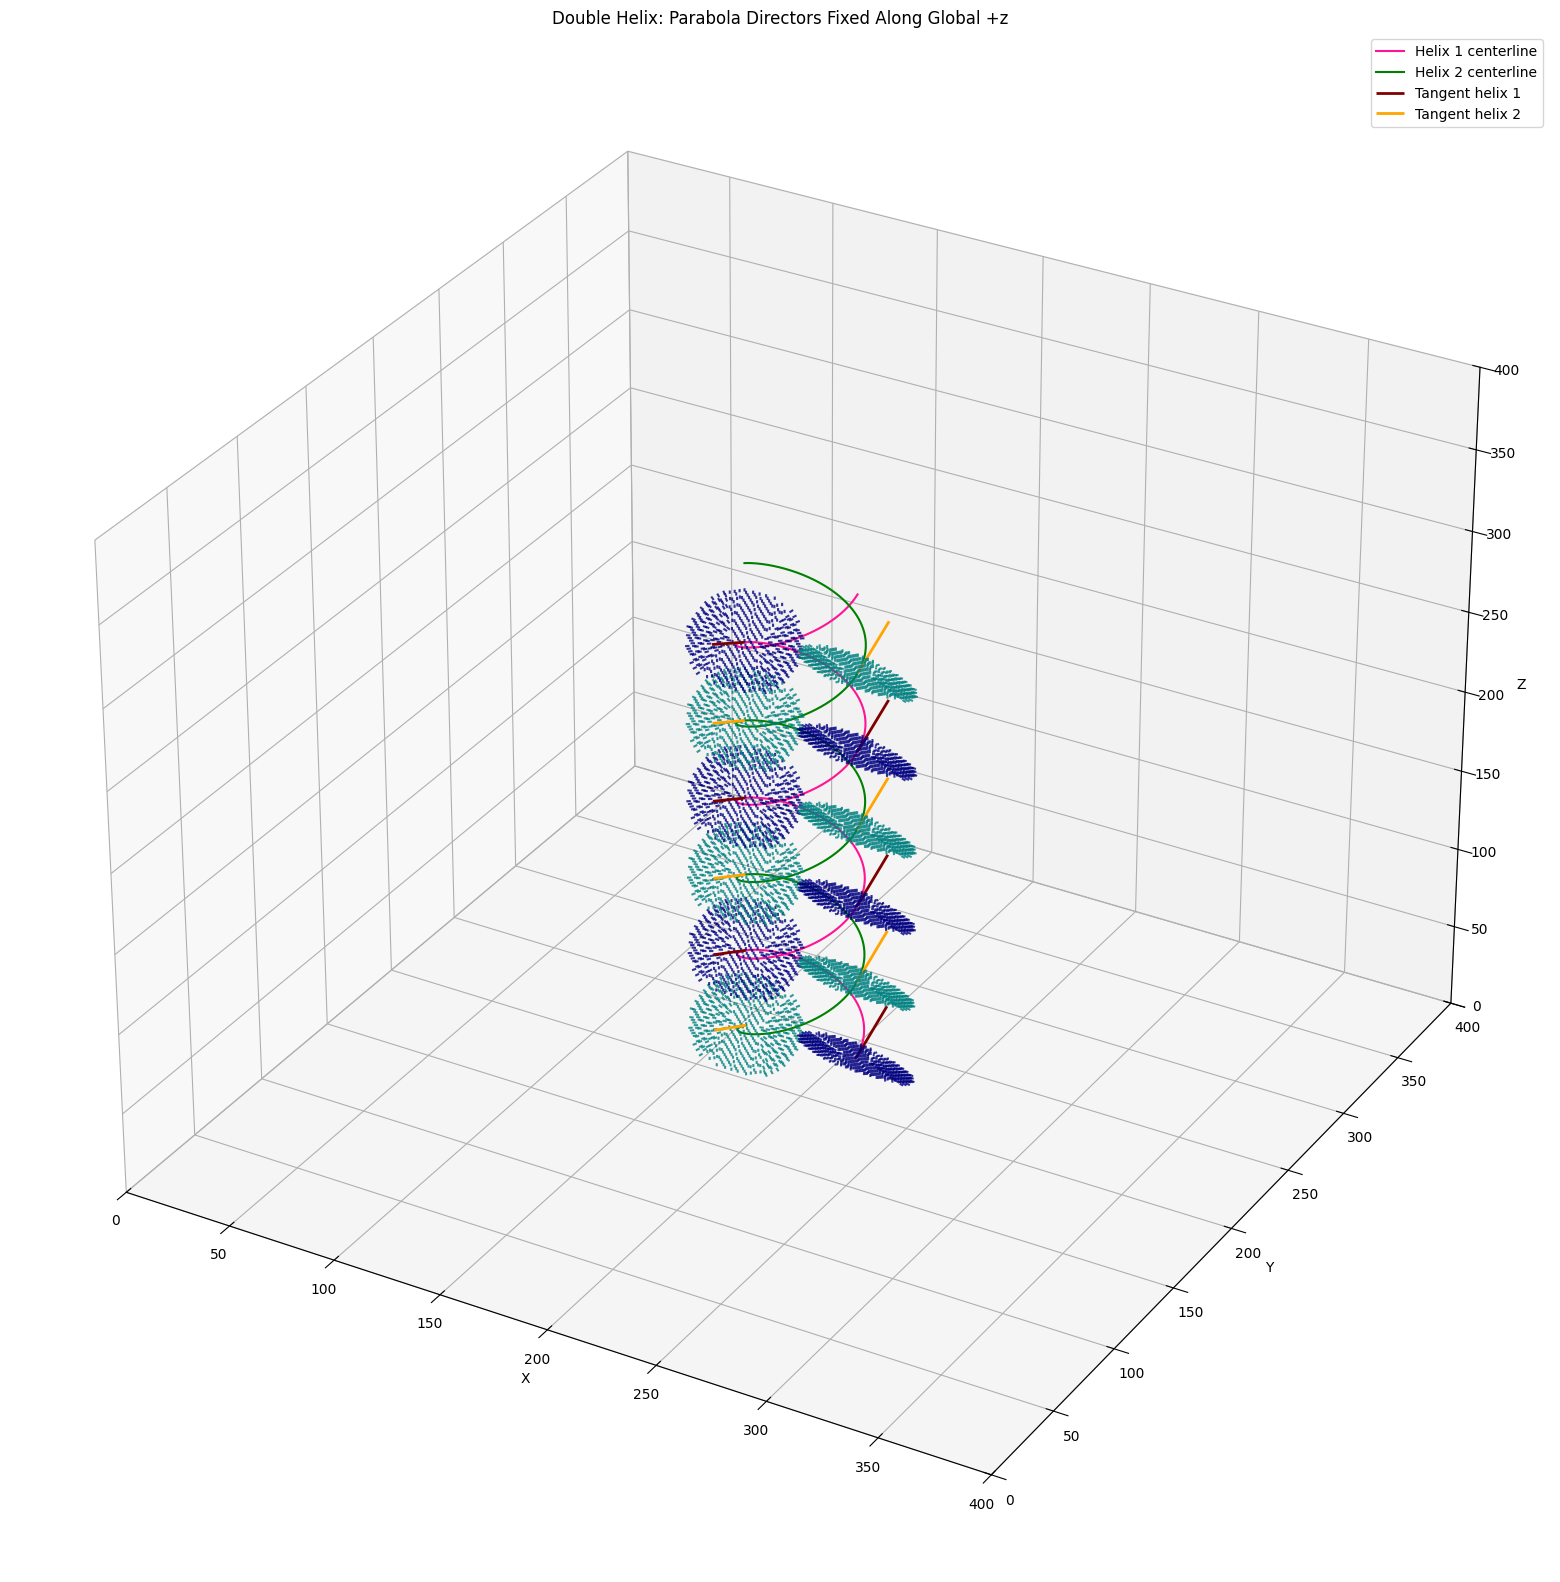

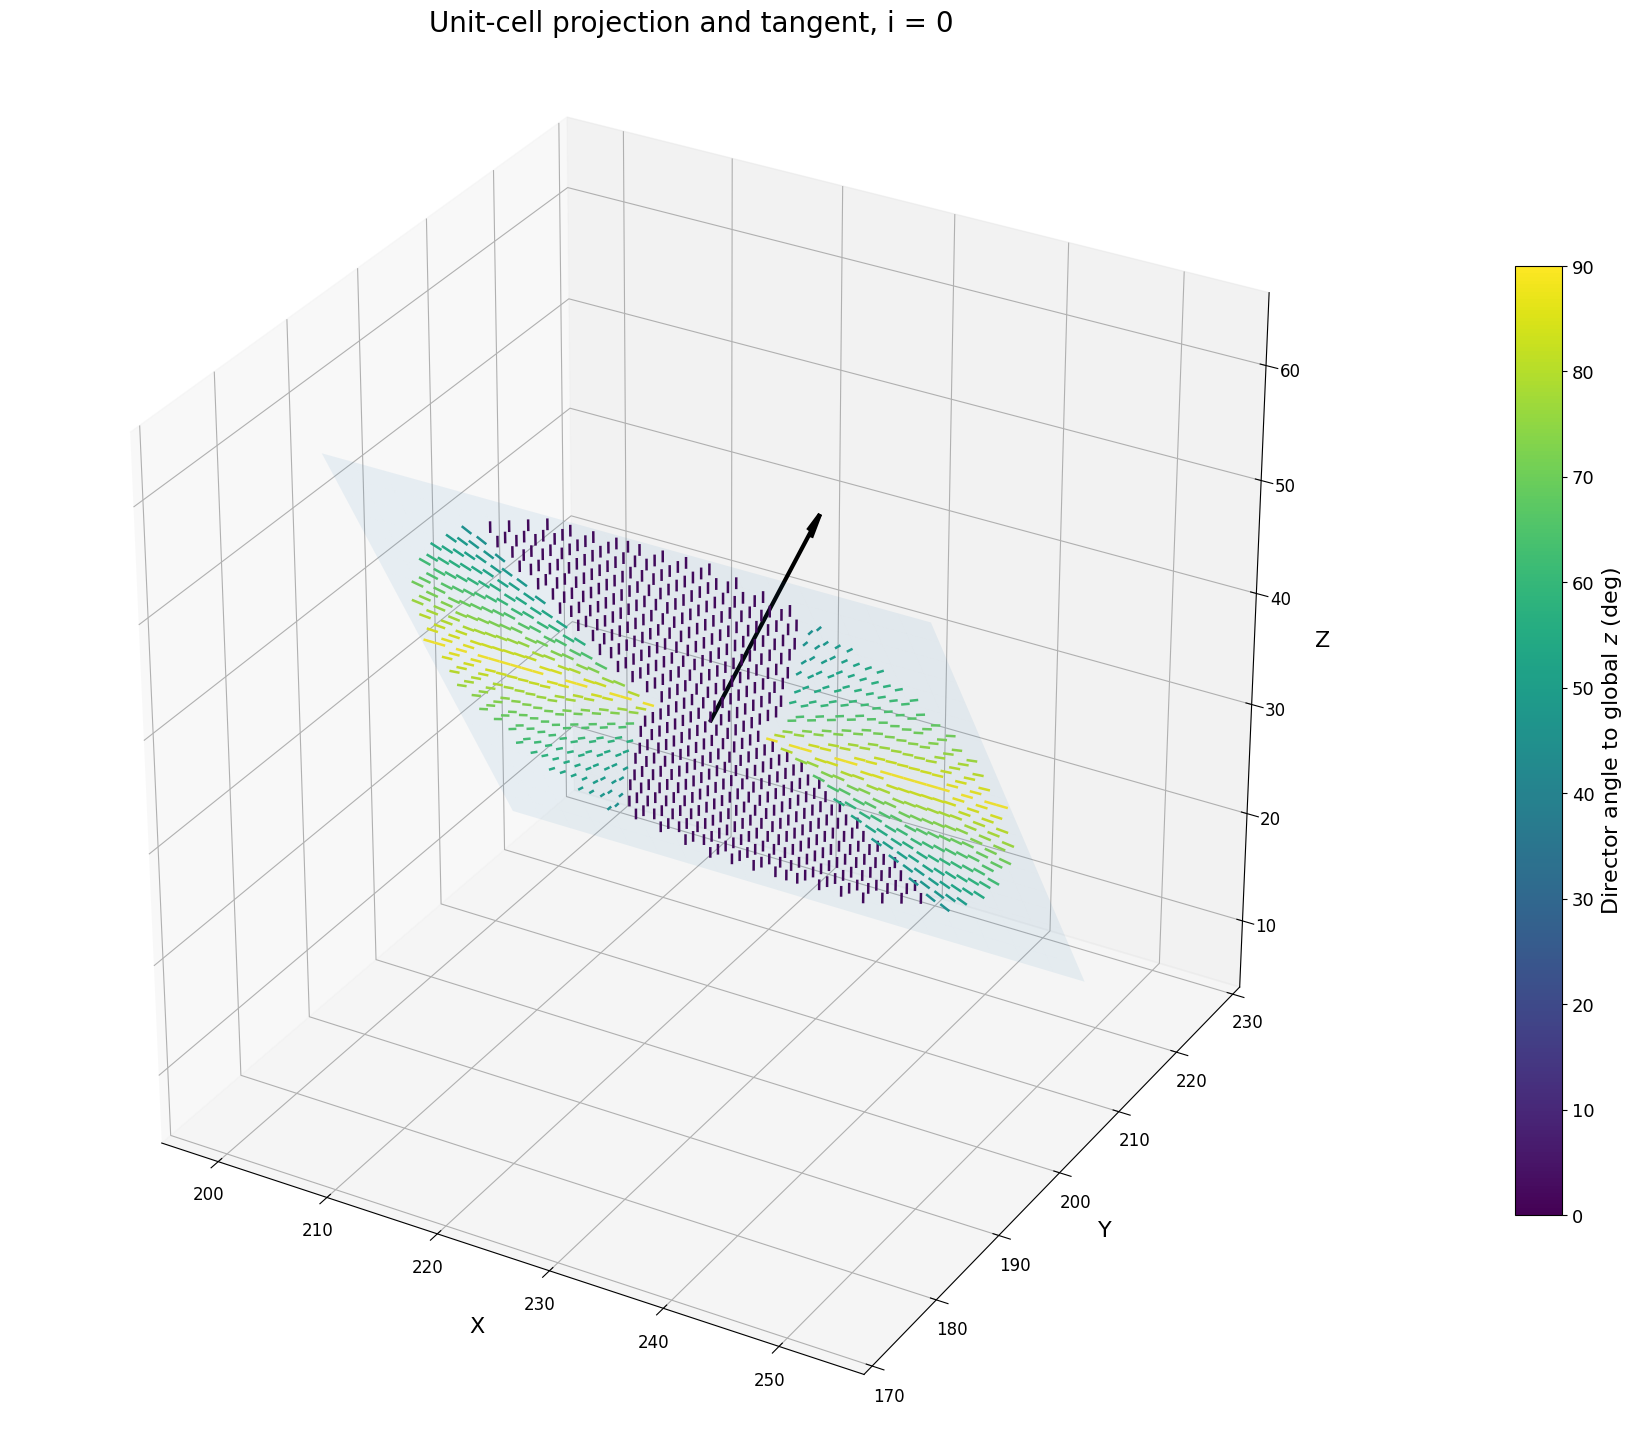

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# CREATE ORIGINAL UNIT CELL + DIRECTOR
# ============================================================

def create_director_circ_w_parabola_both_ways(X, Y, R_f, f):
    r = np.sqrt(X**2+Y**2)

    # Full circular domain
    mask_domain = r <= R_f

    # Parabolas
    parabola_mask1 = 4*f*(Y+f) >= X**2
    parabola_mask2 = 4*f*(-Y+f) >= X**2

    inside_parabola = mask_domain & (parabola_mask1 | parabola_mask2)
    outside_parabola = mask_domain & ~inside_parabola

    # Local 2D director
    nx = np.full_like(X, np.nan, dtype=float)
    ny = np.full_like(Y, np.nan, dtype=float)

    # Vertical director inside parabolas
    nx[inside_parabola] = 0
    ny[inside_parabola] = 1

    # Radial director outside parabolas
    r_safe = np.where(r < 1e-8, 1e-8, r)
    nx[outside_parabola] = X[outside_parabola]/r_safe[outside_parabola]
    ny[outside_parabola] = Y[outside_parabola]/r_safe[outside_parabola]

    return nx, ny, mask_domain, inside_parabola


# ============================================================
# HELIX FUNCTIONS
# ============================================================

def create_helical_path(center, R_h, P, num_points, num_turns, phase=0):
    Cx, Cy, Cz = center

    theta = np.linspace(0, 2*np.pi*num_turns, num_points)
    theta_xy = theta+phase

    X = Cx+R_h*np.cos(theta_xy)
    Y = Cy+R_h*np.sin(theta_xy)
    Z = Cz+(P/(2*np.pi))*theta

    return X, Y, Z, theta, theta_xy


def create_tangent_vectors(R_h, P, theta, theta_xy):
    dx = -R_h*np.sin(theta_xy)
    dy = R_h*np.cos(theta_xy)
    dz = np.full_like(theta, P/(2*np.pi))

    norm = np.sqrt(dx**2+dy**2+dz**2)
    norm[norm == 0] = 1

    return dx/norm, dy/norm, dz/norm


def compute_unit_cell_frame(origin, tangent, helix_center):
    T = tangent/np.linalg.norm(tangent)

    radial_out = np.array([origin[0]-helix_center[0], origin[1]-helix_center[1], 0.0])
    radial_out -= np.dot(radial_out, T)*T
    radial_out /= np.linalg.norm(radial_out)

    u = -radial_out

    v = np.cross(T, u)
    v /= np.linalg.norm(v)

    return u, v


# ============================================================
# BUILD FILAMENT
# ============================================================

def build_filament(X_path, Y_path, Z_path, tangent_x, tangent_y, tangent_z,
                   helix_center, X_local, Y_local, R_f, f):

    filament_points = []
    filament_vectors = []

    nx, ny, mask, inside_parabola = create_director_circ_w_parabola_both_ways(
        X_local, Y_local, R_f, f)

    valid = mask & ~np.isnan(nx) & ~np.isnan(ny)

    X_cell = X_local[valid]
    Y_cell = Y_local[valid]

    nx_cell = nx[valid]
    ny_cell = ny[valid]

    inside_para_cell = inside_parabola[valid]

    for i in range(len(X_path)):
        origin = np.array([X_path[i], Y_path[i], Z_path[i]])
        tangent = np.array([tangent_x[i], tangent_y[i], tangent_z[i]])

        u, v = compute_unit_cell_frame(origin, tangent, helix_center)

        # Place unit-cell points in rotating cross-sectional plane
        global_points = origin+X_cell[:, None]*u+Y_cell[:, None]*v

        global_vectors = np.zeros((len(X_cell), 3))

        # Radial region follows rotating local plane
        radial = ~inside_para_cell

        global_vectors[radial] = (
            nx_cell[radial, None]*u
            + ny_cell[radial, None]*v
        )

        # Parabola region ALWAYS points global +z
        global_vectors[inside_para_cell] = np.array([0.0, 0.0, 1.0])

        filament_points.append(global_points)
        filament_vectors.append(global_vectors)

    return filament_points, filament_vectors


# ============================================================
# PARAMETERS
# ============================================================

Lx = Ly = Lz = 400

R_f = 25.0
Omega_C = 0.17
Rh_over_Rf = 1.04

R_h = Rh_over_Rf*R_f
f = Omega_C*R_f/2

sqrt_arg = 1-(2*R_f*(1-Omega_C)/(np.pi*R_h))**2

if sqrt_arg <= 0:
    raise ValueError("Chosen parameters do not give a valid helix.")

P = 4*R_f*(1-Omega_C)/np.sqrt(sqrt_arg)

theta_p = np.arctan2(2*np.pi*R_h, P)

helix_turns = 3
num_points = 3000

helix_center = np.array([Lx/2, Ly/2, 1.4*R_f])

print(f"R_f = {R_f:.2f}")
print(f"f = {f:.2f}")
print(f"R_h = {R_h:.2f}")
print(f"P = {P:.2f}")
print(f"Helix angle = {np.degrees(theta_p):.2f} deg")


# ============================================================
# DOUBLE HELIX PATHS
# ============================================================

X_path_1, Y_path_1, Z_path_1, theta_1, theta_xy_1 = create_helical_path(
    helix_center, R_h, P, num_points, helix_turns, phase=0)

X_path_2, Y_path_2, Z_path_2, theta_2, theta_xy_2 = create_helical_path(
    helix_center, R_h, P, num_points, helix_turns, phase=np.pi)

tangent_x_1, tangent_y_1, tangent_z_1 = create_tangent_vectors(
    R_h, P, theta_1, theta_xy_1)

tangent_x_2, tangent_y_2, tangent_z_2 = create_tangent_vectors(
    R_h, P, theta_2, theta_xy_2)


# ============================================================
# LOCAL UNIT-CELL GRID
# ============================================================

plane_half_range = 2*R_f
plane_res = int(2*plane_half_range)+1

local_coords = np.linspace(-plane_half_range, plane_half_range, plane_res)
X_local, Y_local = np.meshgrid(local_coords, local_coords, indexing="ij")


# ============================================================
# BUILD BOTH FILAMENTS
# ============================================================

points_1, vectors_1 = build_filament(
    X_path_1, Y_path_1, Z_path_1,
    tangent_x_1, tangent_y_1, tangent_z_1,
    helix_center, X_local, Y_local, R_f, f)

points_2, vectors_2 = build_filament(
    X_path_2, Y_path_2, Z_path_2,
    tangent_x_2, tangent_y_2, tangent_z_2,
    helix_center, X_local, Y_local, R_f, f)

all_global_points = points_1+points_2
all_global_vectors = vectors_1+vectors_2


# ============================================================
# ORIGINAL 3D DOUBLE-HELIX VISUALIZATION
# ============================================================

fig = plt.figure(figsize=(24, 20))
ax = fig.add_subplot(111, projection="3d")

n_p = 500
sample_rate = 4

for i, (pts, vecs) in enumerate(zip(all_global_points, all_global_vectors)):
    if i % n_p == 0:
        color = "navy" if i < num_points else "teal"

        ax.quiver(
            pts[::sample_rate, 0],
            pts[::sample_rate, 1],
            pts[::sample_rate, 2],
            vecs[::sample_rate, 0],
            vecs[::sample_rate, 1],
            vecs[::sample_rate, 2],
            length=2,
            color=color,
            alpha=0.8,
            arrow_length_ratio=0
        )

ax.plot(X_path_1, Y_path_1, Z_path_1, color="deeppink", label="Helix 1 centerline")
ax.plot(X_path_2, Y_path_2, Z_path_2, color="green", label="Helix 2 centerline")

for j, (x, y, z, tx, ty, tz) in enumerate(zip(
        X_path_1, Y_path_1, Z_path_1,
        tangent_x_1, tangent_y_1, tangent_z_1)):

    if j % n_p == 0:
        ax.quiver(x, y, z, tx, ty, tz, length=30, color="maroon", linewidths=2,
                  arrow_length_ratio=0, label="Tangent helix 1" if j == 0 else None)

for j, (x, y, z, tx, ty, tz) in enumerate(zip(
        X_path_2, Y_path_2, Z_path_2,
        tangent_x_2, tangent_y_2, tangent_z_2)):

    if j % n_p == 0:
        ax.quiver(x, y, z, tx, ty, tz, length=30, color="orange", linewidths=2,
                  arrow_length_ratio=0, label="Tangent helix 2" if j == 0 else None)

ax.set_title("Double Helix: Parabola Directors Fixed Along Global +z")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_xlim(0, Lx)
ax.set_ylim(0, Ly)
ax.set_zlim(0, Lz)

ax.legend()

plt.show()


# ============================================================
# SANITY CHECK: ONE UNIT-CELL PLANE
# ============================================================

i = 0
skip = 2
director_length = 1

origin = np.array([X_path_1[i], Y_path_1[i], Z_path_1[i]])
tangent = np.array([tangent_x_1[i], tangent_y_1[i], tangent_z_1[i]])

u, v = compute_unit_cell_frame(origin, tangent, helix_center)

nx, ny, mask, inside_parabola = create_director_circ_w_parabola_both_ways(
    X_local, Y_local, R_f, f)

valid = mask & ~np.isnan(nx) & ~np.isnan(ny)
inside_para_cell = inside_parabola[valid]

pts = points_1[i]
vecs = vectors_1[i]

idx = np.arange(len(pts))[::skip]
pts_plot = pts[idx]
vecs_plot = vecs[idx]


# ============================================================
# COLOR BY DIRECTOR ANGLE TO GLOBAL Z
# ============================================================

vec_norm = np.linalg.norm(vecs_plot, axis=1)
nz = vecs_plot[:, 2]/vec_norm

# n and -n are equivalent
theta_z = np.degrees(np.arccos(np.clip(np.abs(nz), 0, 1)))

cmap = plt.cm.viridis
norm = plt.Normalize(0, 90)
colors = cmap(norm(theta_z))


# ============================================================
# LOCAL CROSS-SECTIONAL PLANE
# ============================================================

s = np.linspace(-1.05*R_f, 1.05*R_f, 20)
S, T = np.meshgrid(s, s)

plane_X = origin[0]+S*u[0]+T*v[0]
plane_Y = origin[1]+S*u[1]+T*v[1]
plane_Z = origin[2]+S*u[2]+T*v[2]


# ============================================================
# SANITY-CHECK PLOT
# ============================================================

fig = plt.figure(figsize=(18, 15))
ax = fig.add_subplot(111, projection="3d")

# Local tangent plane
ax.plot_surface(plane_X, plane_Y, plane_Z, alpha=0.08, shade=False)

# Directors colored by angle to global z
ax.quiver(
    pts_plot[:, 0],
    pts_plot[:, 1],
    pts_plot[:, 2],
    vecs_plot[:, 0],
    vecs_plot[:, 1],
    vecs_plot[:, 2],
    length=director_length,
    colors=colors,
    linewidth=1.8,
    arrow_length_ratio=0
)

# Tangent vector
ax.quiver(
    origin[0],
    origin[1],
    origin[2],
    tangent[0],
    tangent[1],
    tangent[2],
    length=20,
    color="black",
    linewidth=3,
    arrow_length_ratio=0.1
)


# ============================================================
# COLORBAR
# ============================================================

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, shrink=0.65, pad=0.08)
cbar.set_label(r"Director angle to global $z$ (deg)", fontsize=16)
cbar.ax.tick_params(labelsize=13)


# ============================================================
# SANITY-CHECK VIEW
# ============================================================

view_range = 1.25*R_f

ax.set_xlim(origin[0]-view_range, origin[0]+view_range)
ax.set_ylim(origin[1]-view_range, origin[1]+view_range)
ax.set_zlim(origin[2]-view_range, origin[2]+view_range)

ax.set_xlabel("X", fontsize=16, labelpad=12)
ax.set_ylabel("Y", fontsize=16, labelpad=12)
ax.set_zlabel("Z", fontsize=16, labelpad=12)

ax.tick_params(axis="both", labelsize=12)

ax.set_title(f"Unit-cell projection and tangent, i = {i}", fontsize=20, pad=20)

ax.set_box_aspect([1, 1, 1])

ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
all_points_flat = [pts.reshape(-1, 3) for pts in all_global_points]
all_vectors_flat = [vecs.reshape(-1, 3) for vecs in all_global_vectors]


final_points = np.concatenate(all_points_flat, axis=0)  # shape: (N, 3)
final_vectors = np.concatenate(all_vectors_flat, axis=0)

# Replace NaN values with 0
final_points = np.nan_to_num(final_points, nan=0)
final_vectors = np.nan_to_num(final_vectors, nan=0)

# =========================================================
# SAVE FINAL POINTS AND VECTORS
# =========================================================

filename = 'director_raw.npz'

np.savez_compressed(
    filename,
    final_points=final_points,
    final_vectors=final_vectors
)

print(f"Saved: {filename}")
print(f"final_points shape:  {final_points.shape}")
print(f"final_vectors shape: {final_vectors.shape}")

In [ ]:
from scipy.spatial import cKDTree
import multiprocessing as mp
from scipy.interpolate import LinearNDInterpolator, griddata

# Define your maximum allowed distance (set as needed)
max_distance = 1  # for example; adjust to your desired threshold

# Build a KDTree from your scattered global points
tree = cKDTree(final_points)

def interpolate_single_slice(k):

    print(f"Processing z-slice {k}")

    """Interpolate one z-slice using nearest neighbor with a distance threshold.
    
    Returns a (Lx, Ly, 3) float32 array.
    """
    X, Y = np.meshgrid(np.arange(Lx), np.arange(Ly), indexing='ij')
    Z = np.full_like(X, k)
    # Flatten the grid coordinates into (N, 3) points
    grid_coords = np.stack((X, Y, Z), axis=-1).reshape(-1, 3)
    
    # Query the nearest neighbor for each grid point
    distances, indices = tree.query(grid_coords, k=1)
    
    # Retrieve the corresponding vector values from final_vectors
    vectors = final_vectors[indices].copy()  # shape: (N, 3)
    
    # If the nearest neighbor is farther than max_distance, fill with 0
    vectors[distances > max_distance] = 0
    
    # Reshape the result back into grid form
    slice_director = vectors.reshape(X.shape[0], X.shape[1], 3).astype(np.float32)

    print(f"Processing z-slice {k}")
    
    return slice_director



# Use multiprocessing to process each z-slice
with mp.get_context("fork").Pool(processes=4) as pool:
    director_slices = pool.map(interpolate_single_slice, range(Lz))

# Stack slices into a full 4D array: shape (Lx, Ly, Lz, 3)
director = np.stack(director_slices, axis=2)
print("Director field complete! Shape:", director.shape)

In [ ]:
#director[np.isnan(director)] = 0

nx = director[..., 0]
ny = director[..., 1]
nz = director[..., 2]

X, Y, Z = np.meshgrid(np.arange(Lx), np.arange(Ly), np.arange(Lz), indexing='ij')

filename = f"Interpolated_director_Lx{Lx}_Ly{Ly}_Lz{Lz}.npz"

np.savez_compressed(
    filename,
    nx=nx,
    ny=ny,
    nz=nz,
    Lx=Lx,
    Ly=Ly,
    Lz=Lz
)

print(f"Saved: {filename}")

In [ ]:
from scipy.ndimage import affine_transform

def rotate_volume_and_vectors(nx, ny, nz, R):
    R_inv = np.linalg.inv(R)
    center = np.array(nx.shape) / 2

    def apply_rotation(data):
        return affine_transform(
            data,
            matrix=R_inv,
            offset=center - R_inv @ center,
            order=1,
            mode='nearest'
        )

    nx_r = apply_rotation(nx)
    ny_r = apply_rotation(ny)
    nz_r = apply_rotation(nz)

    directors = np.stack([nx_r, ny_r, nz_r], axis=-1)
    rotated = directors @ R.T

    return rotated

In [ ]:
r_e_values = np.array([0.5,0.7,1.0]) * 1e-6  # filament diameters in meters
theta_values = [90]

L_str = Lx           
r_val = R_f
np_val = num_points

In [ ]:
import os

output_dir = "lc-pom/Interpolated_Director_Field"
os.makedirs(output_dir, exist_ok=True)

for r_e in r_e_values:
    # Calculate the grid spacing factor based on r_e and r_s (assumed to be defined)
    res = r_e / R_f
    d_pom = round(res * 1e6, 6)  # grid spacing in micrometers
    #print(d_pom)

    # Set grid spacings (dx, dy, dz) for the simulation
    dx = dy = dz = d_pom

    for theta in theta_values:
        # Convert theta to radians for use in numpy trigonometric functions
        theta_rad = np.radians(theta)
        
        # Build the rotation matrix about the x-axis
        Rx = np.array([
            [1, 0, 0],
            [0, np.cos(theta_rad), -np.sin(theta_rad)],
            [0, np.sin(theta_rad),  np.cos(theta_rad)]
        ])
        
        # Rotate the director field using the provided function
        director_rot = rotate_volume_and_vectors(nx, ny, nz, Rx)
        nx_rot = director_rot[..., 0]
        ny_rot = director_rot[..., 1]
        nz_rot = director_rot[..., 2]
        
        # Stack the director field data along with the grid coordinates
        data = np.stack([
            X.ravel(), Y.ravel(), Z.ravel(),
            nx_rot.ravel(), ny_rot.ravel(), nz_rot.ravel()
        ], axis=1)
        
        # Create header lines for the file (customize if necessary)
        header1 = f"{Lx} {Ly} {Lz} {dx:.4f} {dy:.4f} {dz:.4f}"
        header2 = f"0 {Lx-1} 0 {Ly-1} 0 {Lz-1}"
        
        # Convert r_e to micrometers for the file name display
        re_um = r_e * 1e6
        
        re_str = f"{re_um:.1f}".replace('.', 'p')
        
        r_str = f"{r_val:.1f}".replace('.', 'p')

        o_str = f"{Omega_C:.3f}".replace('.', 'p')

        # Construct the output file name using the current theta and r_e values.
        # Example filename: rotated_90_helix_L_200_r_20_q_1p6_np_16000_re_2p5um.txt
        output_filename = (f"rotated_{theta}_double_helix_L_{L_str}_o_{o_str}_r_{r_str}_"f"np_{np_val}_re_{re_str}um.txt")
        output_path = os.path.join(output_dir, output_filename)
        
        # Write headers and data to the output file
        with open(output_path, 'w') as f:
            f.write(header1 + "\n")
            f.write(header2 + "\n")
            np.savetxt(f, data, fmt="%.6f")
        
        print(header1)
        print(output_filename)